In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Comparison of each method/model to own classification 

Read in compariosn file


In [3]:
csv_comp = pd.read_csv('comparison_file.csv')

use_catalogue_comp = (csv_comp['use_distance'] | csv_comp['only_state_distance']).to_numpy()
methodology_comp = (csv_comp['use_method'] | csv_comp['discuss_method'] | csv_comp['extend_or_alter_method'] | csv_comp['use_other_method']).to_numpy()
comparison_comp = (csv_comp['comparison']).to_numpy()
criticism_comp = (csv_comp['criticism_suggestions_etc']).to_numpy()
background_comp = (csv_comp['general_background_or_passing_mention']).to_numpy()
extension_comp = (csv_comp['extend_or_alter_method']).to_numpy()

bibcode_comp = csv_comp['bibcode'].to_numpy()
citation_context_comp = csv_comp['citation_context_no'].to_numpy()

csv_comp

,bibcode,citation_context_no,use_distance,only_state_distance,use_other_distance,use_method,discuss_method,extend_or_alter_method,use_other_method,general_background_or_passing_mention,criticism_suggestions_etc,comparison,justification,not_classifiable,sentiment
0,2025ApJ...994..133M,1,0,1,0,0,0,0,0,0,0,0,0,0,'neutral'
1,2025ApJ...994..133M,2,0,1,0,0,0,0,0,0,0,0,0,0,'neutral'
2,2025ApJ...994..133M,3,0,1,0,0,0,0,0,0,0,0,0,0,'neutral'
3,2025ApJ...994..133M,4,0,1,0,0,0,0,0,0,0,1,0,0,'neutral'
4,2025ApJ...994..133M,5,1,0,0,0,0,0,0,0,0,0,0,0,'neutral'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,2022MNRAS.514.3579B,2,1,0,0,0,0,0,0,0,0,0,0,0,NaN
200,2021AJ....162...49L,1,0,1,0,0,0,0,0,0,0,0,0,0,NaN
201,2021ApJ...910..114M,1,0,0,0,0,0,0,0,1,0,0,0,0,NaN
202,2020MNRAS.493.4045J,1,1,0,0,0,0,0,0,0,0,0,0,0,NaN


#### Simple zero-shot model with one category: uses_distance and does_not_use_distance

    - output from classify_zeroshot_1cat.ipynb 
    - model "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"

Category:

"The authors adopt or use distance values from Bailer-Jones et al. in their analysis, tables or figures. They do not just cite Bailer-Jones et al. for background, methodology, a passing mention or other non-distance reasons."

In [4]:
# read in results from simple zero shot classification

csv_zeroshot_1cat = pd.read_csv('output_zeroshot_1cat_test.csv')

bibcode_zeroshot_1cat = csv_zeroshot_1cat['bibcode'].to_numpy()
citation_context_zeroshot_1cat = csv_zeroshot_1cat['citation_context_no'].to_numpy()

predicted_label_zeroshot_1cat = csv_zeroshot_1cat['predicted_label'].to_numpy()
use_catalogue_zeroshot_1cat = np.where(predicted_label_zeroshot_1cat == 'uses_distance_catalogue', 1, 0)
distance_used_score_zeroshot_1cat = csv_zeroshot_1cat['distance_used_score'].to_numpy()

In [5]:
false_positives_zeroshot_1cat = []
false_negatives_zeroshot_1cat = []
true_positives_zeroshot_1cat = []
true_negatives_zeroshot_1cat = []

for i in range(len(bibcode_comp)):

    if bibcode_comp[i] == bibcode_zeroshot_1cat[i]:
        if use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_1cat[i] == 1:
            true_positives_zeroshot_1cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_1cat[i]])

        elif use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_1cat[i] == 0:
            false_negatives_zeroshot_1cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_1cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_1cat[i] == 1:
            false_positives_zeroshot_1cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_1cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_1cat[i] == 0:
            true_negatives_zeroshot_1cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_1cat[i]])
    else:
        print(f"Warning: Bibcodes do not match at index {i}: {bibcode_comp[i]} vs {bibcode_zeroshot_1cat[i]}")        

print(f"correctly assigned catalogue usage: {len(true_positives_zeroshot_1cat)}")
print(f"incorrectly assigned catalogue usage: {len(false_positives_zeroshot_1cat)}")
print(f"correctly assigned non-usage: {len(true_negatives_zeroshot_1cat)}")
print(f"incorrectly assigned non-usage: {len(false_negatives_zeroshot_1cat)}")

correctly assigned catalogue usage: 104
incorrectly assigned catalogue usage: 34
correctly assigned non-usage: 36
incorrectly assigned non-usage: 30


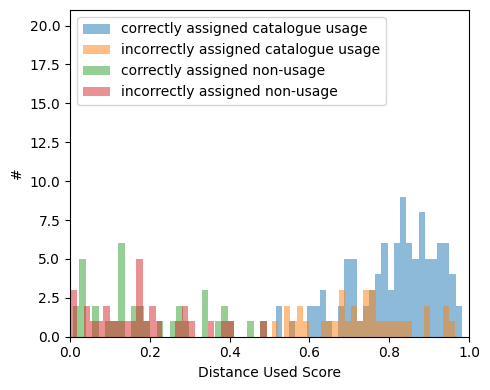

In [6]:
fig,ax = plt.subplots(1,1, figsize=(5,4))

ax.set_xlabel('Distance Used Score')
ax.set_ylabel('#')
ax.set_xlim(0,1)
ax.set_ylim(0, 21)

ax.hist([tp[2] for tp in true_positives_zeroshot_1cat], bins=30, alpha=0.5, label='correctly assigned catalogue usage')
ax.hist([fp[2] for fp in false_positives_zeroshot_1cat], bins=30, alpha=0.5, label='incorrectly assigned catalogue usage')
ax.hist([tn[2] for tn in true_negatives_zeroshot_1cat], bins=30, alpha=0.5, label='correctly assigned non-usage')
ax.hist([fn[2] for fn in false_negatives_zeroshot_1cat], bins=30, alpha=0.5, label='incorrectly assigned non-usage')

ax.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

#### Simple zero-shot model with two categories: uses_distance and does_not_use_distance

    - output from classify_zeroshot_2cat.ipynb, classifies as uses_distance if uses_distance score >0.5 and as does_not_use_distance if does_not_use_distance score >0.5
    - model "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"

Categories:

    "The authors adopt or use distance values from Bailer-Jones et al. in their analysis, tables or figures.",
    "The authors cite Bailer-Jones et al. for background, methodology, a passing mention or other non-distance reasons."

In [7]:
# read in results from simple zero shot classification

csv_zeroshot_2cat = pd.read_csv('output_zeroshot_2cat_test.csv')

bibcode_zeroshot_2cat = csv_zeroshot_2cat['bibcode'].to_numpy()
citation_context_zeroshot_2cat = csv_zeroshot_2cat['citation_context'].to_numpy()

predicted_label_zeroshot_2cat = csv_zeroshot_2cat['predicted_label'].to_numpy()
use_catalogue_zeroshot_2cat = np.where(predicted_label_zeroshot_2cat == 'uses_distance_catalogue', 1, 0)
distance_used_score_zeroshot_2cat = csv_zeroshot_2cat['distance_used_score'].to_numpy()
distance_not_used_score_zeroshot_2cat = csv_zeroshot_2cat['distance_not_used_score'].to_numpy()


In [8]:
false_positives_zeroshot_2cat = []
false_negatives_zeroshot_2cat = []
true_positives_zeroshot_2cat = []
true_negatives_zeroshot_2cat = []

for i in range(len(bibcode_comp)):

    if bibcode_comp[i] == bibcode_zeroshot_2cat[i]:
        if use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_2cat[i] == 1:
            true_positives_zeroshot_2cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_2cat[i]])

        elif use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_2cat[i] == 0:
            false_negatives_zeroshot_2cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_2cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_2cat[i] == 1:
            false_positives_zeroshot_2cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_2cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_2cat[i] == 0:
            true_negatives_zeroshot_2cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_2cat[i]])
    else:
        print(f"Warning: Bibcodes do not match at index {i}: {bibcode_comp[i]} vs {bibcode_zeroshot_2cat[i]}")        

print(f"True Positives: {len(true_positives_zeroshot_2cat)}")
print(f"False Positives: {len(false_positives_zeroshot_2cat)}")
print(f"True Negatives: {len(true_negatives_zeroshot_2cat)}")
print(f"False Negatives: {len(false_negatives_zeroshot_2cat)}")

True Positives: 133
False Positives: 68
True Negatives: 2
False Negatives: 1


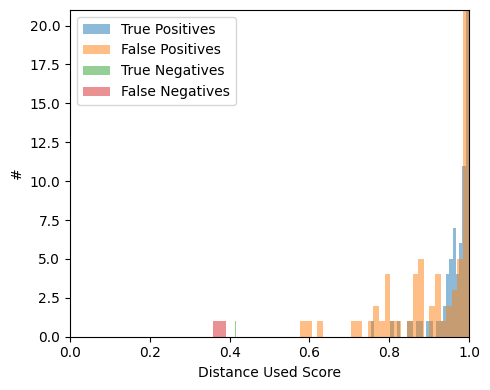

In [9]:
fig,ax = plt.subplots(1,1, figsize=(5,4))


ax.set_xlabel('Distance Used Score')
ax.set_ylabel('#')
ax.set_xlim(0,1)
ax.set_ylim(0, 21)

ax.hist([tp[2] for tp in true_positives_zeroshot_2cat], bins=30, alpha=0.5, label='True Positives')
ax.hist([fp[2] for fp in false_positives_zeroshot_2cat], bins=30, alpha=0.5, label='False Positives')
ax.hist([tn[2] for tn in true_negatives_zeroshot_2cat], bins=30, alpha=0.5, label='True Negatives')
ax.hist([fn[2] for fn in false_negatives_zeroshot_2cat], bins=30, alpha=0.5, label='False Negatives')

ax.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

#### 2. text-generation model with two categories: uses_distance and does_not_use_distance

    - output from classify_simple.ipynb with only using the text-generation model, so classifies as uses_distance if uses_distance score >1 and as does_not_use_distance if does_not_use_distance score >1
    - model: "Qwen/Qwen2.5-7B-Instruct"

In [10]:
csv_textgen_2cat = pd.read_csv('output_textgen_2cat_test.csv')
csv_textgen_2cat


bibcode_textgen_2cat = csv_textgen_2cat['bibcode'].to_numpy()
citation_context_textgen_2cat = csv_textgen_2cat['citation_context'].to_numpy()

predicted_label_textgen_2cat = csv_textgen_2cat['predicted_label'].to_numpy()
use_catalogue_textgen_2cat = np.where(predicted_label_textgen_2cat == 'uses_distance_catalogue', 1, 0)



In [13]:
false_positives_textgen_2cat = []
false_negatives_textgen_2cat = []
true_positives_textgen_2cat = []
true_negatives_textgen_2cat = []

for i in range(len(bibcode_comp)):

    if bibcode_comp[i] == bibcode_textgen_2cat[i]:
        if use_catalogue_comp[i] == 1 and use_catalogue_textgen_2cat[i] == 1:
            true_positives_textgen_2cat.append([bibcode_comp[i], citation_context_comp[i]])

        elif use_catalogue_comp[i] == 1 and use_catalogue_textgen_2cat[i] == 0:
            false_negatives_textgen_2cat.append([bibcode_comp[i], citation_context_comp[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_textgen_2cat[i] == 1:
            false_positives_textgen_2cat.append([bibcode_comp[i], citation_context_comp[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_textgen_2cat[i] == 0:
            true_negatives_textgen_2cat.append([bibcode_comp[i], citation_context_comp[i]])
    else:
        print(f"Warning: Bibcodes do not match at index {i}: {bibcode_comp[i]} vs {bibcode_textgen_2cat[i]}")        

print(f"True Positives: {len(true_positives_textgen_2cat)}")
print(f"False Positives: {len(false_positives_textgen_2cat)}")
print(f"True Negatives: {len(true_negatives_textgen_2cat)}")
print(f"False Negatives: {len(false_negatives_textgen_2cat)}")

True Positives: 95
False Positives: 17
True Negatives: 53
False Negatives: 39


#### 3. sentiment analysis: positive, negative, neutral

- output from classify_sentiment.py
- model: 'ProsusAI/finbert'

In [14]:
csv_sentiment = pd.read_csv('output_sentiment_test.csv')
csv_sentiment

,bibcode,citation_context_no,citation_context,target_reference,sentiment_result,score
0,2025ApJ...994..133M,1,"6.3). Thus, it is likely that the upper limits...",bj_2021,neutral,0.920233
1,2025ApJ...994..133M,2,"Fortunately, however, for the most compact Q+E...",bj_2021,neutral,0.910174
2,2025ApJ...994..133M,3,93 663+27 -24 33.0+1.3 -1.2 42.0+1.7 -1.5 · · ...,bj_2021,neutral,0.910986
3,2025ApJ...994..133M,4,3.6.2. TIC 266771301 Table 6 contains five Q+E...,bj_2021,neutral,0.922934
4,2025ApJ...994..133M,5,Here we have focused on multi-filter speckle i...,bj_2021,neutral,0.931006
...,...,...,...,...,...,...
199,2022MNRAS.514.3579B,2,- that share the same kinematics as those pred...,bj_2021,neutral,0.805990
200,2021AJ....162...49L,1,Although the presence of ω-Ωand 2(ω-Ω) is cons...,bj_2021,neutral,0.942302
201,2021ApJ...910..114M,1,15 mag for Sgr (Monaco et al. 2004) and (m -M)...,bj_2015,neutral,0.683463
202,2020MNRAS.493.4045J,1,These detached systems may or may not have a s...,bj_2018,neutral,0.933383


In [15]:
print(csv_sentiment['sentiment_result'].value_counts())
print('')
print('positive:')
print(csv_sentiment[csv_sentiment['sentiment_result'].isin(['positive'])][['bibcode','citation_context']])
print('')
print('negative:')
print(csv_sentiment[csv_sentiment['sentiment_result'].isin(['negative'])][['bibcode','citation_context']])

sentiment_result
neutral     200
negative      4
Name: count, dtype: int64

positive:
Empty DataFrame
Columns: [bibcode, citation_context]
Index: []

negative:
                 bibcode                                   citation_context
142  2022A&A...668A..21L  The number of MaStar targets that satisfy this...
156  2019A&A...627A.104D  2019). This choice, which is the result of the...
161  2019A&A...627A.104D  However, the fraction of distant stars in Bail...
162  2019A&A...627A.104D  However, the fraction of distant stars in Bail...


4. #### Simple zero-shot model with 3 categories: uses_distance and mehodology or other

    - output from classify_zeroshot_3cat.py
    - model "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"

In [16]:
csv_zeroshot_3cat = pd.read_csv('output_zeroshot_3cat_test.csv')


bibcode_zeroshot_3cat = csv_zeroshot_3cat['bibcode'].to_numpy()
citation_context_zeroshot_3cat = csv_zeroshot_3cat['citation_context'].to_numpy()

predicted_label_zeroshot_3cat = csv_zeroshot_3cat['predicted_label'].to_numpy()
use_catalogue_zeroshot_3cat = np.where(predicted_label_zeroshot_3cat == 'distance_used', 1, 0)
methodology_zeroshot_3cat = np.where(predicted_label_zeroshot_3cat == 'methodology', 1, 0)
other_zeroshot_3cat = np.where(predicted_label_zeroshot_3cat == 'other', 1, 0)

distance_used_score_zeroshot_3cat = csv_zeroshot_3cat['distance_used_score'].to_numpy()
methodology_score_zeroshot_3cat = csv_zeroshot_3cat['methodology_score'].to_numpy()
other_score_zeroshot_3cat = csv_zeroshot_3cat['other_score'].to_numpy()

csv_zeroshot_3cat


,bibcode,citation_context_no,citation_context,target_reference,predicted_label,distance_used_score,methodology_score,other_score
0,2025ApJ...994..133M,1,"6.3). Thus, it is likely that the upper limits...",bj_2021,methodology,0.784567,0.784979,0.002497
1,2025ApJ...994..133M,2,"Fortunately, however, for the most compact Q+E...",bj_2021,distance_used,0.982339,0.580040,0.000499
2,2025ApJ...994..133M,3,93 663+27 -24 33.0+1.3 -1.2 42.0+1.7 -1.5 · · ...,bj_2021,distance_used,0.843959,0.324744,0.000349
3,2025ApJ...994..133M,4,3.6.2. TIC 266771301 Table 6 contains five Q+E...,bj_2021,methodology,0.052570,0.369912,0.014757
4,2025ApJ...994..133M,5,Here we have focused on multi-filter speckle i...,bj_2021,distance_used,0.728314,0.727250,0.001242
...,...,...,...,...,...,...,...,...
199,2022MNRAS.514.3579B,2,- that share the same kinematics as those pred...,bj_2021,methodology,0.346541,0.789396,0.003559
200,2021AJ....162...49L,1,Although the presence of ω-Ωand 2(ω-Ω) is cons...,bj_2021,methodology,0.073497,0.270336,0.027118
201,2021ApJ...910..114M,1,15 mag for Sgr (Monaco et al. 2004) and (m -M)...,bj_2015,methodology,0.036873,0.700741,0.000940
202,2020MNRAS.493.4045J,1,These detached systems may or may not have a s...,bj_2018,distance_used,0.882883,0.866979,0.000190


In [17]:
false_positives_distance_used_zeroshot_3cat = []
false_negatives_distance_used_zeroshot_3cat = []
true_positives_distance_used_zeroshot_3cat = []
true_negatives_distance_used_zeroshot_3cat = []

false_positives_methodology_zeroshot_3cat = []
false_negatives_methodology_zeroshot_3cat = []
true_positives_methodology_zeroshot_3cat = []
true_negatives_methodology_zeroshot_3cat = []

false_positives_other_zeroshot_3cat = []
false_negatives_other_zeroshot_3cat = []
true_positives_other_zeroshot_3cat = []
true_negatives_other_zeroshot_3cat = []


for i in range(len(bibcode_comp)):

    if bibcode_comp[i] == bibcode_zeroshot_3cat[i]:
        if use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_3cat[i] == 1:
            true_positives_distance_used_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_3cat[i]])

        elif use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_3cat[i] == 0:
            false_negatives_distance_used_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_3cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_3cat[i] == 1:
            false_positives_distance_used_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_3cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_3cat[i] == 0:
            true_negatives_distance_used_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], distance_used_score_zeroshot_3cat[i]])


        if methodology_comp[i]== 1 and methodology_zeroshot_3cat[i] == 1:
            true_positives_methodology_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], methodology_score_zeroshot_3cat[i]])

        elif methodology_comp[i] == 1 and methodology_zeroshot_3cat[i] == 0:
            false_negatives_methodology_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], methodology_score_zeroshot_3cat[i]])

        elif methodology_comp[i] == 0 and methodology_zeroshot_3cat[i] == 1:
            false_positives_methodology_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], methodology_score_zeroshot_3cat[i]])

        elif methodology_comp[i] == 0 and methodology_zeroshot_3cat[i] == 0:
            true_negatives_methodology_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], methodology_score_zeroshot_3cat[i]])


        if background_comp[i]== 1 and other_zeroshot_3cat[i] == 1:
            true_positives_other_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], other_score_zeroshot_3cat[i]])

        elif background_comp[i] == 1 and other_zeroshot_3cat[i] == 0:
            false_negatives_other_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], other_score_zeroshot_3cat[i]])

        elif background_comp[i] == 0 and other_zeroshot_3cat[i] == 1:
            false_positives_other_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], other_score_zeroshot_3cat[i]])

        elif background_comp[i] == 0 and other_zeroshot_3cat[i] == 0:
            true_negatives_other_zeroshot_3cat.append([bibcode_comp[i], citation_context_comp[i], other_score_zeroshot_3cat[i]])


        

    else:
        print(f"Warning: Bibcodes do not match at index {i}: {bibcode_comp[i]} vs {bibcode_zeroshot_3cat[i]}")        

print('Distance used:')
print('')
print(f"True Positives: {len(true_positives_distance_used_zeroshot_3cat)}")
print(f"False Positives: {len(false_positives_distance_used_zeroshot_3cat)}")
print(f"True Negatives: {len(true_negatives_distance_used_zeroshot_3cat)}")
print(f"False Negatives: {len(false_negatives_distance_used_zeroshot_3cat)}")
print('')

print('Methodology:')
print('')
print(f"True Positives: {len(true_positives_methodology_zeroshot_3cat)}")
print(f"False Positives: {len(false_positives_methodology_zeroshot_3cat)}")
print(f"True Negatives: {len(true_negatives_methodology_zeroshot_3cat)}")
print(f"False Negatives: {len(false_negatives_methodology_zeroshot_3cat)}")
print('')
print('Other:')

print(f"True Positives: {len(true_positives_other_zeroshot_3cat)}")
print(f"False Positives: {len(false_positives_other_zeroshot_3cat)}")
print(f"True Negatives: {len(true_negatives_other_zeroshot_3cat)}")
print(f"False Negatives: {len(false_negatives_other_zeroshot_3cat)}")

Distance used:

True Positives: 47
False Positives: 6
True Negatives: 64
False Negatives: 87

Methodology:

True Positives: 42
False Positives: 108
True Negatives: 45
False Negatives: 9

Other:
True Positives: 0
False Positives: 1
True Negatives: 165
False Negatives: 38


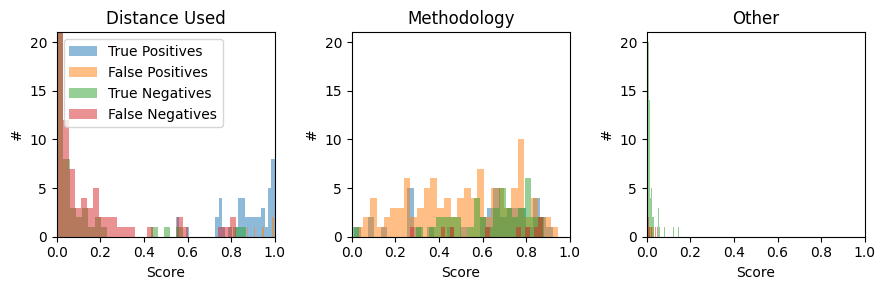

In [29]:
fig,ax = plt.subplots(1,3, figsize=(9,3))


ax[0].set_xlabel('Score')
ax[0].set_ylabel('#')
ax[0].set_xlim(0,1)
ax[0].set_ylim(0, 21)
ax[0].set_title('Distance Used')

ax[0].hist([tp[2] for tp in true_positives_distance_used_zeroshot_3cat], bins=30, alpha=0.5, label='True Positives')
ax[0].hist([fp[2] for fp in false_positives_distance_used_zeroshot_3cat], bins=30, alpha=0.5, label='False Positives')
ax[0].hist([tn[2] for tn in true_negatives_distance_used_zeroshot_3cat], bins=30, alpha=0.5, label='True Negatives')
ax[0].hist([fn[2] for fn in false_negatives_distance_used_zeroshot_3cat], bins=30, alpha=0.5, label='False Negatives')

ax[1].set_xlabel('Score')
ax[1].set_ylabel('#')
ax[1].set_xlim(0,1)
ax[1].set_ylim(0, 21)
ax[1].set_title('Methodology')

ax[1].hist([tp[2] for tp in true_positives_methodology_zeroshot_3cat], bins=30, alpha=0.5, label='True Positives')
ax[1].hist([fp[2] for fp in false_positives_methodology_zeroshot_3cat], bins=30, alpha=0.5, label='False Positives')
ax[1].hist([tn[2] for tn in true_negatives_methodology_zeroshot_3cat], bins=30, alpha=0.5, label='True Negatives')
ax[1].hist([fn[2] for fn in false_negatives_methodology_zeroshot_3cat], bins=30, alpha=0.5, label='False Negatives')

ax[2].set_xlabel('Score')
ax[2].set_ylabel('#')
ax[2].set_xlim(0,1)
ax[2].set_ylim(0, 21)
ax[2].set_title('Other')

ax[2].hist([tp[2] for tp in true_positives_other_zeroshot_3cat], bins=30, alpha=0.5, label='True Positives')
ax[2].hist([fp[2] for fp in false_positives_other_zeroshot_3cat], bins=30, alpha=0.5, label='False Positives')
ax[2].hist([tn[2] for tn in true_negatives_other_zeroshot_3cat], bins=30, alpha=0.5, label='True Negatives')
ax[2].hist([fn[2] for fn in false_negatives_other_zeroshot_3cat], bins=30, alpha=0.5, label='False Negatives')


ax[0].legend(loc = 'upper left')
plt.tight_layout()